In [ ]:
import marimo as mo

# Drift-Corrected Noise Model for CBS Systems

## Model Overview

This analysis implements a drift-corrected noise model for CBS based FHE. The core insight is that the encoded positions on the torus are affected by three independent noise components as a circuit progresses.

1. Offset: Position of the encoded torus element with random offset, with standard deviation $\sigma_0$
2. Linear drift: Drifting position error with slope $m$, characterized by the standard deviation $\sigma_m$
3. Spread: Depth-dependent random noise representing the error on top of the drifting torus position due to inherent noise in LWE based FHE schemes with standard deviation $\sigma_s(d)$

## Mathematical Framework and Torus Visualization

As a spoiler, we end up with the following estimate for the standard deviation representing the potential positions of an encoded message over circuit depth $d$ in CBS FHE.

$$\sigma^2_{total}(d) = \sigma_0^2 + d^2 \sigma_m^2 + \sigma_s^2(d)$$

The visualization below demonstrates how these noise components affect error rates on the torus. The torus represents the message space where 0.5 (top) encodes message 1 and 0.0 (bottom) encodes message 0. The ±0.25 boundaries (red dashed lines) separate valid decoding regions - noise beyond these boundaries causes decryption failure as values drift into the incorrect encoding region.

The figure shows three different scenarios:

- Initial: Encoding with only the initial noise
- Spread Only: FHE operational noise model without assuming the encoding position drifts
- Drift-Corrected: Model showing systematic position drift on top of the spreading distribution.

The key insight is that drift moves the entire noise distribution away from the intended encoding position, increasing the probability that distribution tails cross into failure regions.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
from statistics import NormalDist

# Configure matplotlib for publication quality
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "axes.grid": True,
        "grid.alpha": 0.6,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
    }
)

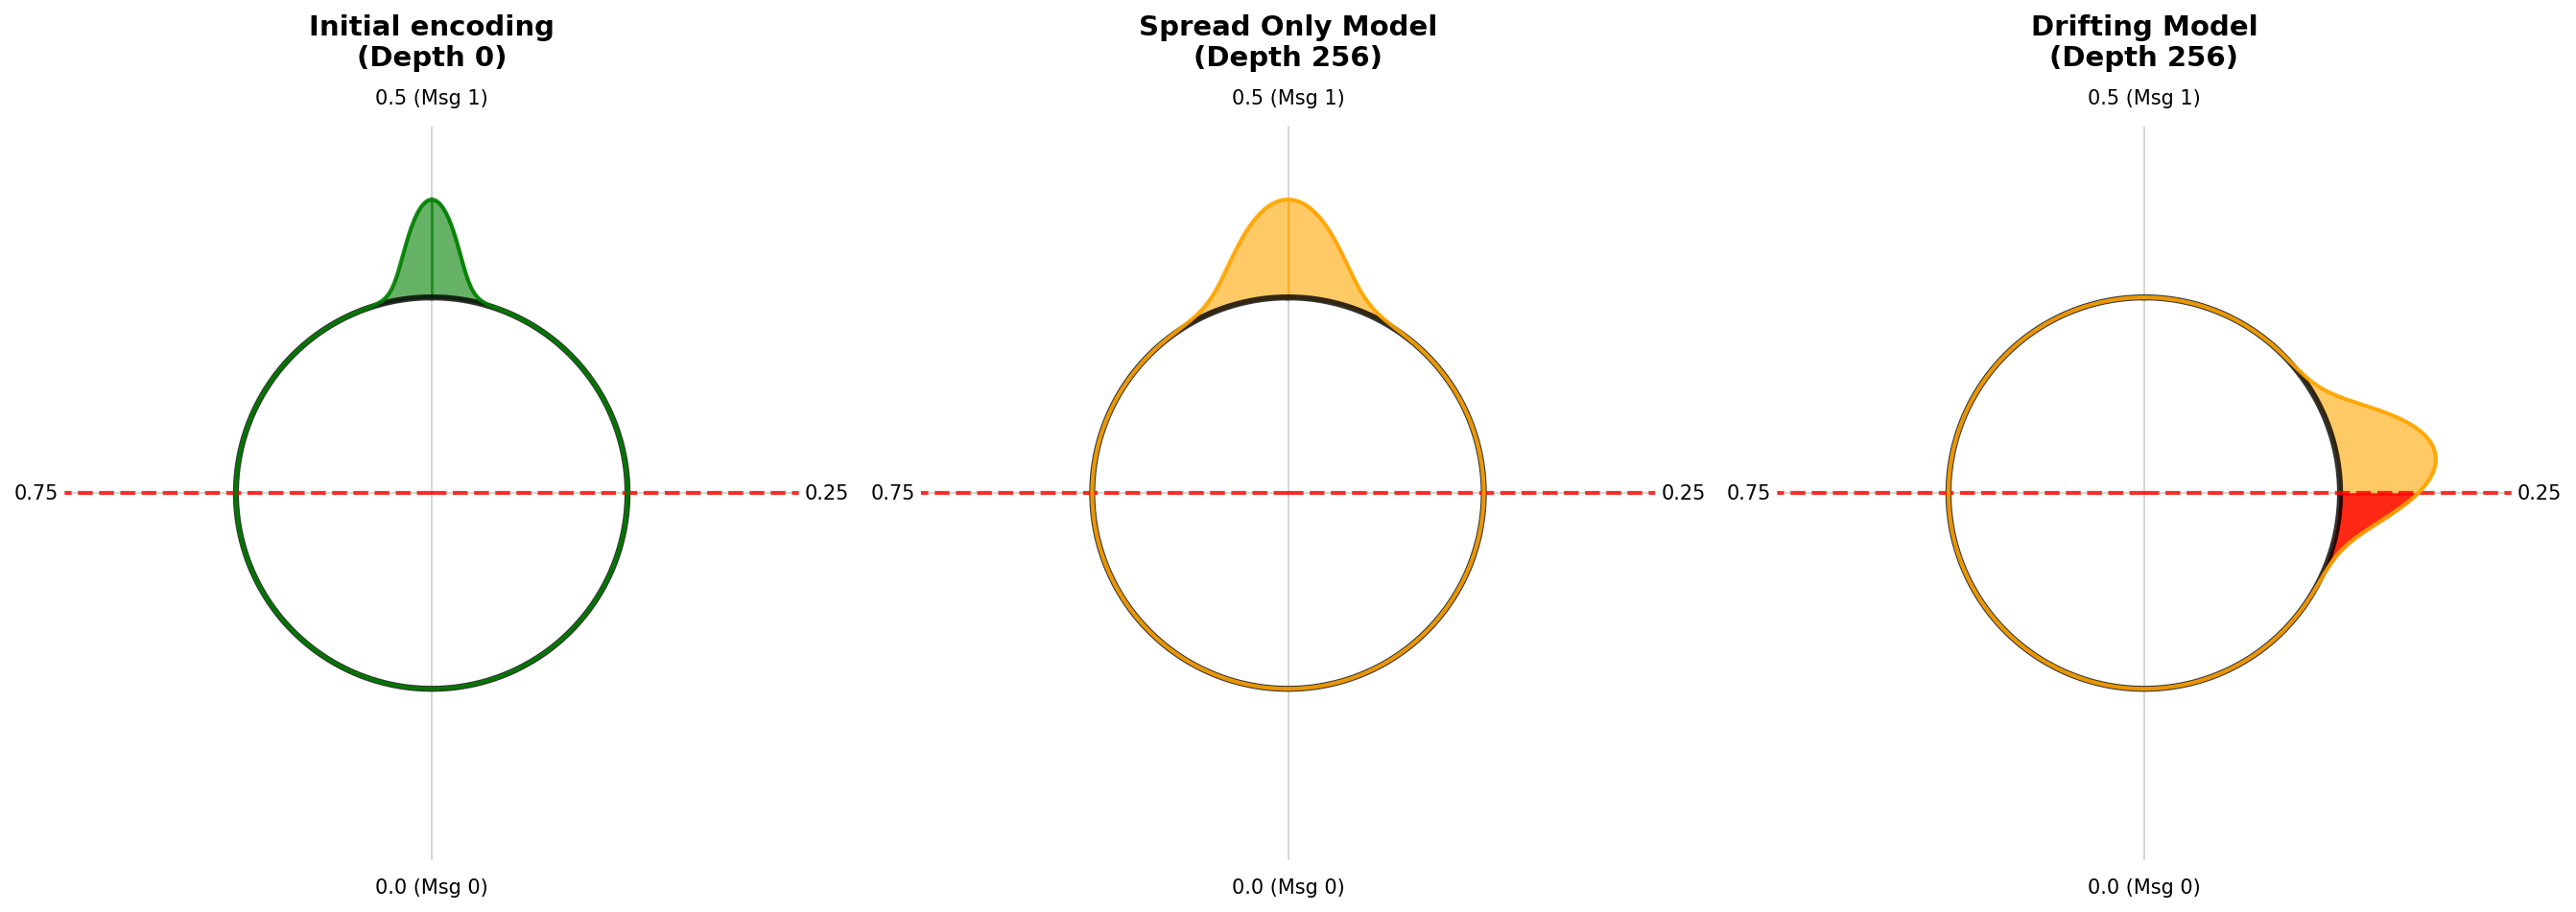

In [ ]:
# Create torus visualization for the mathematical framework
def create_torus_visualization():
    fig, axes = plt.subplots(
        1, 3, figsize=(18, 6), subplot_kw=dict(projection="polar")
    )

    # Use representative values for visualization
    baseline_std = 0.030300  # Representative spread-only std
    drift_variance = 0.000043  # Representative drift variance

    # Convert torus position to angle (0.5 should be at top = θ=0)
    def torus_to_angle(pos):
        return (-pos * 2 * np.pi) % (2 * np.pi)

    # Failure boundaries (±0.25 from 0.5)
    boundary_1 = torus_to_angle(0.25)  # 0.25
    boundary_2 = torus_to_angle(0.75)  # 0.75

    # Scenarios to visualize - keep drift realistic but visible
    drift_offset = np.sqrt(drift_variance)
    scenarios = [
        (
            "Initial encoding",
            0,
            baseline_std / 2,
            0.0,
        ),  # Tiny noise for visualization
        ("Spread Only Model", 256, baseline_std, 0.0),
        (
            "Drifting Model",
            256,
            baseline_std,
            0.0 + drift_offset * 35,
        ),  # Small visible drift within top region
    ]

    colors = ["green", "orange", "orange"]

    for idx, (title, depth, noise_std, mean_pos) in enumerate(scenarios):
        ax = axes[idx]

        # Draw the torus circle
        circle_theta = np.linspace(0, 2 * np.pi, 1000)
        circle_r = np.ones_like(circle_theta) * 0.8
        ax.plot(circle_theta, circle_r, "k-", linewidth=3, alpha=0.8)

        # Draw failure boundaries
        ax.axvline(
            boundary_1, color="red", linestyle="--", alpha=0.8, linewidth=2
        )
        ax.axvline(
            boundary_2, color="red", linestyle="--", alpha=0.8, linewidth=2
        )

        # Show noise distribution
        if noise_std > 0.0001:  # Only if significant noise
            # Convert mean position to angle
            mean_angle = torus_to_angle(mean_pos % 1.0)

            # Create detailed Gaussian distribution on the circle
            n_points = 500
            angles = np.linspace(0, 2 * np.pi, n_points)

            # Calculate probability density at each angle
            probabilities = []
            for angle in angles:
                # Convert angle back to torus position
                torus_pos = (-angle / (2 * np.pi)) % 1.0
                # Distance from mean (considering torus wraparound)
                dist = min(
                    abs(torus_pos - (mean_pos % 1.0)),
                    abs(torus_pos - (mean_pos % 1.0) - 1.0),
                    abs(torus_pos - (mean_pos % 1.0) + 1.0),
                )
                # Gaussian probability
                prob = np.exp(-0.5 * (dist / noise_std) ** 2)
                probabilities.append(prob)

            probabilities = np.array(probabilities)

            # Normalize and scale for visualization
            probabilities = probabilities / np.max(probabilities)
            radii = (
                0.8 + 0.4 * probabilities
            )  # Scale to make distribution visible

            # Plot distribution curve
            ax.fill_between(
                angles,
                0.8,
                radii,
                alpha=0.6,
                color=colors[idx],
                label="Noise Distribution",
            )
            ax.plot(angles, radii, color=colors[idx], linewidth=2, alpha=0.9)

            # Highlight failure regions in distribution
            failure_probs = []
            for i, angle in enumerate(angles):
                torus_pos = (-angle / (2 * np.pi)) % 1.0
                # Check if in failure region (> 0.25 away from message 1 at 0.5)
                distance_from_msg1 = min(
                    abs(torus_pos - 0.5),
                    abs(torus_pos - 0.5 + 1.0),
                    abs(torus_pos - 0.5 - 1.0),
                )
                if distance_from_msg1 > 0.25:
                    failure_probs.append(radii[i])
                else:
                    failure_probs.append(0.8)

            # Highlight the tail regions that cause failures
            failure_mask = np.array(failure_probs) <= 0.8
            if np.any(failure_mask):
                ax.fill_between(
                    angles,
                    0.8,
                    radii,
                    where=failure_mask,
                    alpha=0.8,
                    color="red",
                    interpolate=True,
                    label="Error-causing Tails",
                )

        # Formatting
        ax.set_title(
            f"{title}\n(Depth {depth})", pad=30, fontsize=14, fontweight="bold"
        )
        ax.set_ylim(0, 1.5)
        ax.set_rticks([])  # Hide radial ticks
        # ax.grid(True, alpha=0.3)
        ax.set_theta_zero_location("N")  # Put 0° at the top

        # Set custom angle labels (0.5 at top = 0°)
        ax.set_thetagrids(
            [0, 90, 180, 270], ["0.5 (Msg 1)", "0.75", "0.0 (Msg 0)", "0.25"]
        )
        ax.spines["polar"].set_visible(False)

    plt.tight_layout()
    plt.show()


create_torus_visualization()

## Experimental Data Overview

Our analysis is based on two complementary experiments measuring noise characteristics in CMUX operations:

**Experiment 1: Drift Characterization**

We execute multiple independent CMUX trees (a new secret key for each tree), each run to moderate depth (~512 levels). For each tree:

- Generate GGSW ciphertexts encoding random 0/1 values
- At each level, randomly select two ciphertexts as select inputs for CMUX operations
- Track the encoded position on the torus as operations accumulate
- Extract two key parameters: initial position offset and linear drift rate

This experiment reveals that drift follows a predictable linear pattern for all depths, with both offset and slope being normally distributed.

**Experiment 2: Spread Analysis**

We run a single deep CMUX tree (up to ~5000 levels) many times using:

- Fixed cryptographic keys
- Fixed GGSW select lines that are reordered randomly before running the CMUX tree.
- Keyswitch operations from GLWE to LWE to measure accumulated noise
- Standard deviation measurements at each depth

This captures the inherent noise growth from FHE operations, independent of the systematic drift measured in Experiment 1. We should note that the observed drift in this case is constant for each CMUX tree run; the drift appears to be a function of the generated compute keys.

Together, these experiments allow us to decompose total system noise into interpretable components for accurate error rate prediction.

In [ ]:
# Load experimental data
import os

data_files = [
    "../../../../noise_analysis/analyze_cmux_tree.json",
    "../../../noise_analysis/analyze_cmux_tree.json",
    "../../noise_analysis/analyze_cmux_tree.json",
    "../noise_analysis/analyze_cmux_tree.json",
    "analyze_cmux_tree.json",
]

results = None
for filename in data_files:
    if os.path.exists(filename):
        with open(filename, "r") as f:
            results = json.load(f)
        print(f"Loaded data from: {filename}")
        break

if results is None:
    raise FileNotFoundError(
        "No data file found. Please run the noise analysis tool first."
    )

# Extract key parameters
spread_sample_count = results["cmux_tree_parameters"]["run_options"][
    "spread_sample_count"
]

Loaded data from: ../../../../noise_analysis/analyze_cmux_tree.json


In [ ]:
# Parse experimental data
drift_data = results["drift_data"]
spread_data = results["spread_data"]

# Extract arrays for analysis
depths = np.array([x["depth"] for x in spread_data])
measured_stds = np.array([x["std"] for x in spread_data])
measured_means = np.array([x["mean"] for x in spread_data])
measured_errors = np.array([x["measured_err"] for x in spread_data])

# Drift analysis arrays
drift_raw = np.array(results["drift_raw"])
drift_slopes = np.array([d["drift"] for d in drift_data])
drift_offsets = np.array([d["offset"] for d in drift_data])
drift_max_errors = np.array([d["max_error"] for d in drift_data])

## Mathematical Framework for Noise Decomposition

Remember that we are using this model for characterizing the standard deviation in the message position over circuit depth:

$$\sigma^2_{total}(d) = \sigma_0^2 + d^2 \sigma_m^2 + \sigma_s^2(d)$$

where

- $\sigma_0^2$: Initial position offset variance - captures randomness in starting torus position
- $\sigma_m^2$: Drift variance - distribution of drift slope
- $\sigma_s^2(d)$: Depth-dependent spread - intrinsic FHE noise growth from cryptographic operations

This decomposition allows us to separately characterize drift (from Experiment 1) and spread based noise (from Experiment 2), and then combine those experiments to characterize the total error at a given circuit depth $d$.

In [ ]:
# Functions for fitting experimental data
def gaussian_pdf(x, mean, std):
    """
    Standard Gaussian probability density function.

    Parameters
    ----------
    x : array_like
        Input values at which to evaluate the PDF
    mean : float
        Mean of the Gaussian distribution
    std : float
        Standard deviation of the Gaussian distribution

    Returns
    -------
    array_like
        Probability density values at each x
    """
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def rational_model(x, a, b, c):
    """
    Rational function model for depth-dependent spread.

    Parameters
    ----------
    x : array_like
        Depth values
    a : float
        Scale parameter
    b : float
        Offset parameter
    c : float
        Asymptotic value parameter

    Returns
    -------
    array_like
        Modeled spread values at each depth
    """
    return -1 / (a * (x + b)) + c


# Drift variance model functions
def drift_variance_model(depth, var_offset, var_drift):
    """
    Variance contribution from drift components only.

    Parameters
    ----------
    depth : float or array_like
        CMUX tree depth
    var_offset : float
        Variance of initial position offset (σ₀²)
    var_drift : float
        Variance of drift slope (σₘ²)

    Returns
    -------
    float or array_like
        Total drift variance: σ₀² + d² * σₘ²
    """
    return var_offset + (depth**2) * var_drift


def total_variance_model(depth, var_offset, var_drift, var_spread):
    """
    Total system variance including all noise sources.

    Parameters
    ----------
    depth : float or array_like
        CMUX tree depth
    var_offset : float
        Variance of initial position offset (σ₀²)
    var_drift : float
        Variance of drift slope (σₘ²)
    var_spread : float or array_like
        Depth-dependent spread variance from FHE operations (σₛ²(d))

    Returns
    -------
    float or array_like
        Total variance: σ₀² + d² * σₘ² + σₛ²(d)
    """
    return drift_variance_model(depth, var_offset, var_drift) + var_spread


def total_std_model(depth, std_offset, std_drift, std_spread):
    """
    Total system standard deviation.

    Parameters
    ----------
    depth : float or array_like
        CMUX tree depth
    std_offset : float
        Standard deviation of initial position offset (σ₀²)
    std_drift : float
        Standard deviation of drift slope (σₘ²)
    std_spread : float or array_like
        Depth-dependent spread standard deviation from FHE operations (σₛ²(d))

    Returns
    -------
    float or array_like
        Total standard deviation: √(σ₀² + d² * σₘ² + σₛ²(d))
    """
    return np.sqrt(
        total_variance_model(depth, std_offset**2, std_drift**2, std_spread**2)
    )

We have almost all the pieces we need. First we need to find an empirical model for determining $\sigma_s(d)$, the depth-dependent spread variance from FHE operations. We do this by fitting the spread data to the rational model defined above.

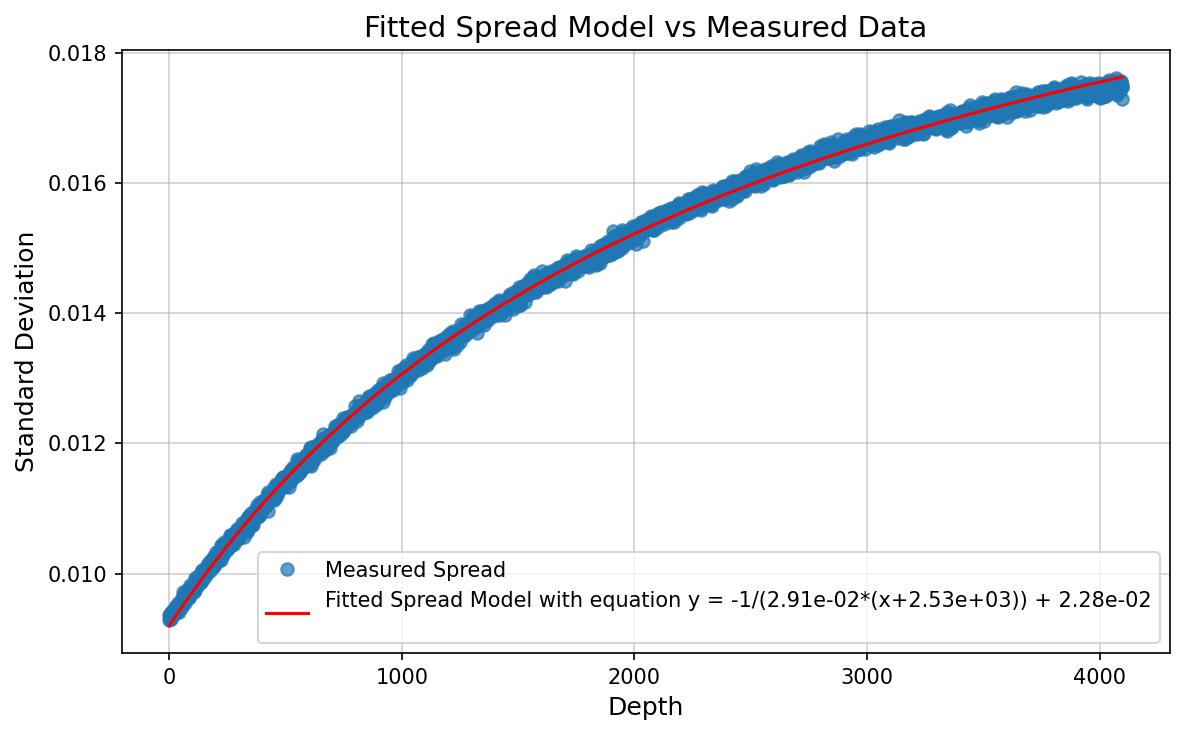

In [ ]:
# Fit a model to the spread data
def fit_spread_std(depths, stds):
    """
    Fit a rational model to the spread data.

    Parameters
    ----------
    depths : array_like
        Array of CMUX tree depths
    stds : array_like
        Measured standard deviations at each depth

    Returns
    -------
    tuple
        (parameters, fitted_function) where parameters is the optimized
        coefficients and fitted_function is a callable
    """
    # Fit the curve
    a = 6.0e-6
    b = 0.002
    c = -3.0

    popt, pcov = curve_fit(
        rational_model,
        depths,
        stds,
        p0=[a, b, c],
        method="trf",
        loss="linear",  # Linear least squares loss function
    )

    # Create the fit function
    def fit_function(depth):
        return rational_model(depth, *popt)

    # Return the fitted function and the parameters
    return (popt, fit_function)


# Fit the spread model to the measured data
(popt, fitted_spread_model) = fit_spread_std(depths, measured_stds)

# Plot the results to ensure we have a good fit
plt.figure(figsize=(8, 5))
plt.plot(
    depths,
    measured_stds,
    "o",
    label="Measured Spread",
    alpha=0.7,
)
depth_fit = np.linspace(depths.min(), depths.max(), 100)
plt.plot(
    depth_fit,
    fitted_spread_model(depth_fit),
    "r-",
    label=f"Fitted Spread Model with equation y = -1/({popt[0]:.2e}*(x+{popt[1]:.2e})) + {popt[2]:.2e}\n",
)
plt.xlabel("Depth")
plt.ylabel("Standard Deviation")
plt.title("Fitted Spread Model vs Measured Data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

And we need to mesure the drift based distributions $\sigma_0$ and $\sigma_m$. Those calculations are simple (the standard deviation); here we provide an additional check on our assumption that these distributions are indeed well modeled by a Gaussian distribution and are independent.

In [ ]:
# Compute drift statistics
std_offset = np.std(drift_offsets)
std_drift = np.std(drift_slopes)

In [ ]:
# Drift distribution analysis
plt.figure(figsize=(12, 4))

# Plot drift component distributions
plt.subplot(1, 3, 1)
plt.hist(drift_offsets, bins=51, alpha=0.7, density=True, label="Observed")
x_offset = np.linspace(drift_offsets.min(), drift_offsets.max(), 100)
plt.plot(
    x_offset,
    gaussian_pdf(x_offset, 0, std_offset),
    "r-",
    label="Gaussian fit",
)
plt.xlabel("Offset Drift")
plt.ylabel("Density")
plt.title("Offset Distribution")
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(drift_slopes, bins=51, alpha=0.7, density=True, label="Observed")
x_slope = np.linspace(drift_slopes.min(), drift_slopes.max(), 100)
plt.plot(
    x_slope, gaussian_pdf(x_slope, 0, std_drift), "r-", label="Gaussian fit"
)
plt.xlabel("Slope Drift")
plt.ylabel("Density")
plt.title("Slope Distribution")
plt.legend()

# Correlation analysis. Should use a z-score
z_scores_offsets = (drift_offsets - np.mean(drift_offsets)) / np.std(
    drift_offsets
)
z_scores_slopes = (drift_slopes - np.mean(drift_slopes)) / np.std(drift_slopes)

plt.subplot(1, 3, 3)
plt.scatter(z_scores_offsets, z_scores_slopes, alpha=0.7)
correlation = np.corrcoef(z_scores_offsets, z_scores_slopes)[0, 1]
plt.xlabel("Offset Drift z-scored")
plt.ylabel("Slope Drift z-scored")
plt.title(f"Drift Correlation (r={correlation:.3f})")
plt.axis("equal")


plt.tight_layout()
plt.show()

print(f"Drift correlation coefficient: {correlation:.4f}")

# Statistical tests for drift distributions
# Note: With large N, Shapiro-Wilk W statistic is more reliable than p-value
(offset_statistic, offset_pvalue) = stats.shapiro(drift_offsets)
(slope_statistic, slope_pvalue) = stats.shapiro(drift_slopes)

print(f"\nShapiro-Wilk Test (N={len(drift_offsets)}):")
print(f"  Offset: W={offset_statistic:.4f}")
print(f"  Slope:  W={slope_statistic:.4f}")
print("Drift components can be modeled as independent Gaussian variables.")

Drift correlation coefficient: -0.0802


/nix/store/nnjg16x43bqlp0ilsvlwnhhh8xvlv52c-python3-3.13.4-env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20000.
  res = hypotest_fun_out(*samples, **kwds)



Shapiro-Wilk Test (N=20000):
  Offset: W=0.9999
  Slope:  W=0.9998
Drift components can be modeled as independent Gaussian variables.


Now that we have the estimates for $\sigma_0$, $\sigma_m$, and $\sigma_s(d)$, we can calculate the error rate for a given depth $d$ using the drift-corrected noise model.

## Decryption error probability from torus position probability distributions

Our measure of the decryption error probability is defined as the percentage of the area of the torus message probability distribution that lies in another encoded value. In the case of binary message (which is what we are working with), this is a measure of the probability that message value is more than half a torus away from the noiseless encoded position.

In the following code, we must split the error rate calculation into two parts based on the ratio of the range of the encoded value to the standard deviation.

- When the ratio is low, we can calculate the area of the probability distribution that lies outside the valid encoded value range directly.
- When the ratio is high, we can use a simple polynomial approximation for the percentage of the probability curve outside of the valid encoded value range. This returns a log10 answer, as otherwise the returned answers are far too close to the limits of floating point number representations.

In [ ]:
def _error_rate_low_ratio(failure_point, std):
    """
    Calculate error rate when failure_point/std ratio is low (< 7).

    Parameters
    ----------
    failure_point : float
        Distance to encoding boundary
    std : float
        Standard deviation of the noise

    Returns
    -------
    float
        Log₁₀ of error probability
    """
    center_probability = NormalDist().cdf(failure_point / std) * 2 - 1
    return np.log10(1 - center_probability)


def _error_rate_high_ratio(failure_point, std):
    """
    Calculate error rate when failure_point/std ratio is high (≥ 7).

    Parameters
    ----------
    failure_point : float
        Distance to encoding boundary
    std : float
        Standard deviation of the noise

    Returns
    -------
    float
        Log₁₀ of error probability

    Notes
    -----
    Returns NaN if ratio exceeds 30 (approximation limit)
    """
    ratio = failure_point / std

    if ratio > 30.0:
        return np.nan

    # Listed lowest power first
    coeffs = np.array(
        [
            -0.31753523501161746,
            -0.13432742899666797,
            -0.20898218668225407,
            -0.00031997376011370216,
            6.802772902435344e-06,
            -5.9592564195036294e-08,
        ]
    )

    error_rate = 0.0

    for i, c in enumerate(coeffs):
        error_rate += c * ratio**i

    return error_rate


def error_rate(failure_point, std):
    """
    Calculate the error rate for binary encoding scheme.

    Parameters
    ----------
    failure_point : float
        Distance to encoding boundary (0.25 for binary)
    std : float
        Standard deviation of the noise

    Returns
    -------
    float
        Log₁₀ of error probability (e.g., -30 means error rate of 10^-30)
    """
    ratio = failure_point / std

    if ratio < 7.0:
        return _error_rate_low_ratio(failure_point, std)
    else:
        return _error_rate_high_ratio(failure_point, std)

In [ ]:
# Model validation and error prediction
def compute_model_error_rate(depth):
    """
    Compute error rate using the complete drift-corrected model.

    Parameters
    ----------
    depth : float
        CMUX tree depth at which to compute error rate

    Returns
    -------
    float
        Log₁₀ of error probability

    Notes
    -----
    For binary encoding, failure occurs when noise exceeds ±0.25 torus units.
    """
    spread_std = fitted_spread_model(depth)
    total_std = total_std_model(depth, std_offset, std_drift, spread_std)

    # Since we have a binary scheme, the threshold is always 0.25
    return error_rate(0.25, total_std)


# Compute predictions across depth range
baseline_error_rates = np.array(
    [error_rate(0.25, std) for std in measured_stds]
)

model_error_rates = np.array([compute_model_error_rate(d) for d in depths])

# Convert to base-2 for interpretability
baseline_error_rates_b2 = baseline_error_rates / np.log10(2)
model_error_rates_b2 = model_error_rates / np.log10(2)

Since we have all of the estimated distributions and a function to calculate our decryption error from it, we can finally plot how our probability of decryption failure changes over circuit depth and compare it to our old spread only model.

In [ ]:
# Error rate comparison
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    baseline_error_rates_b2,
    label="Spread only",
    linewidth=4,
)
plt.plot(
    depths,
    model_error_rates_b2,
    label="Drift-corrected model",
    linewidth=4,
)

plt.xlabel("Depth")
plt.ylabel("Error Rate Exponent (base 2)")
plt.title("Error Rate Prediction: Spread vs Drift-Corrected Model")
plt.legend()
plt.grid(True, alpha=0.3)

# Add annotation for key depths
key_depth = 256
key_idx = np.argmin(np.abs(depths - key_depth))
error_difference = (
    model_error_rates_b2[key_idx] - baseline_error_rates_b2[key_idx]
)

plt.tight_layout()
plt.show()

print(f"At depth {key_depth}:")
print(f"Spread model: 2^{baseline_error_rates_b2[key_idx]:.1f}")
print(f"Drift-corrected: 2^{model_error_rates_b2[key_idx]:.1f}")
if error_difference > 0:
    print(
        f"Baseline underestimates error by factor of 2^{error_difference:.1f}"
    )

At depth 256:
Spread model: 2^-420.4
Drift-corrected: 2^-300.4
Baseline underestimates error by factor of 2^120.0


We can see that the error rate increases much more significantly with depth when accounting for drift.

In [ ]:
# Utility function for predictions at arbitrary depths
def predict_error_rate(depth):
    """
    Predict error rate at arbitrary depth using the drift-corrected model.

    Parameters
    ----------
    depth : float or array_like
        CMUX tree depth (scalar or array)

    Returns
    -------
    float or array_like
        Log₁₀ error rate (e.g., -30 means error rate of 10^-30)
    """
    if np.isscalar(depth):
        return compute_model_error_rate(depth)
    else:
        return np.array([compute_model_error_rate(d) for d in depth])


# Example predictions
test_depths = [100, 256, 512]
for d in test_depths:
    error_rate_b10 = predict_error_rate(d)
    error_rate_b2 = error_rate_b10 / np.log10(2)
    print(
        f"Depth {d:3d}: Error rate ≈ 2^{error_rate_b2:.1f} ≈ 10^{error_rate_b10:.1f}"
    )

Depth 100: Error rate ≈ 2^-386.9 ≈ 10^-116.5
Depth 256: Error rate ≈ 2^-300.4 ≈ 10^-90.4
Depth 512: Error rate ≈ 2^-188.5 ≈ 10^-56.7
